# TabPFN-3 Demo

This notebook will demo how to synthesize tabular data using TabPFN-3.

In [8]:
from dotenv import load_dotenv
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.unsupervised import TabPFNUnsupervisedModel
from tabpfgen import TabPFGen
from tabpfgen.visuals import visualize_classification_results

load_dotenv()

True

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (284, 30), (284,)
Test data shape: (285, 30), (285,)


In [3]:
print(f"Unique target values: {set(y)}")

Unique target values: {0, 1}


In [ ]:
clf = TabPFNClassifier()
clf.fit(X_train, y_train)
prediction_probabilities = clf.predict_proba(X_test)
predictions = clf.predict(X_test)
print("Accuracy", accuracy_score(y_test, predictions))

Accuracy 0.9789473684210527


In [5]:
# Generate synthetic data using the unsupervised model
reg = TabPFNRegressor()

model_unsupervised = TabPFNUnsupervisedModel(tabpfn_clf=clf, tabpfn_reg=reg)

model_unsupervised.fit(
    np.hstack([load_breast_cancer().data, load_breast_cancer().target.reshape(-1, 1)])
)

synthetic_df = model_unsupervised.generate_synthetic_data(
    n_samples=500,
)

print(f"Synthetic data shape: {synthetic_df.numpy().shape}")

 19%|█▉        | 6/31 [01:16<06:22, 15.32s/it]/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:157: RuntimeWarning: overflow encountered in expm1
  x_inv[pos] = np.expm1(
/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:157: RuntimeWarning: overflow encountered in expm1
  x_inv[pos] = np.expm1(
/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:157: RuntimeWarning: overflow encountered in expm1
  x_inv[pos] = np.expm1(
/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:157: RuntimeWarning: overflow encountered in expm1
  x_inv[pos] = np.expm1(
/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:157: RuntimeWarning: over

Synthetic data shape: (500, 31)


In [6]:
synthetic_df = pd.DataFrame(
    synthetic_df.numpy(),
    columns=load_breast_cancer().feature_names.tolist() + ["target"],
)
synthetic_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,20.015347,32.119591,133.024750,1213.192017,0.098326,0.190052,0.174317,0.114355,0.200554,0.063382,...,44.219795,165.467148,1817.967285,0.147062,0.441060,0.455492,0.207052,0.304909,0.092902,0.0
1,11.866204,19.637781,76.072090,434.532623,0.094962,0.071422,0.030839,0.012191,0.154043,0.058724,...,28.156883,85.827049,533.532776,0.138647,0.164124,0.199829,0.067067,0.260313,0.073503,1.0
2,15.357289,14.539530,97.448372,726.572876,0.083251,0.041452,0.006451,0.014105,0.172706,0.055372,...,17.207680,103.854370,792.553040,0.102850,0.069639,0.028247,0.053519,0.227172,0.073734,1.0
3,10.111999,16.247179,64.965561,311.474091,0.095911,0.082892,0.062049,0.017332,0.162401,0.062739,...,23.950993,77.495750,374.042053,0.135609,0.220812,0.247230,0.068197,0.250996,0.079293,1.0
4,13.152756,16.843830,84.046539,525.387268,0.091603,0.067311,0.041994,0.029071,0.142567,0.061161,...,25.980888,91.107903,618.920532,0.132416,0.183119,0.192015,0.080186,0.249005,0.085508,1.0


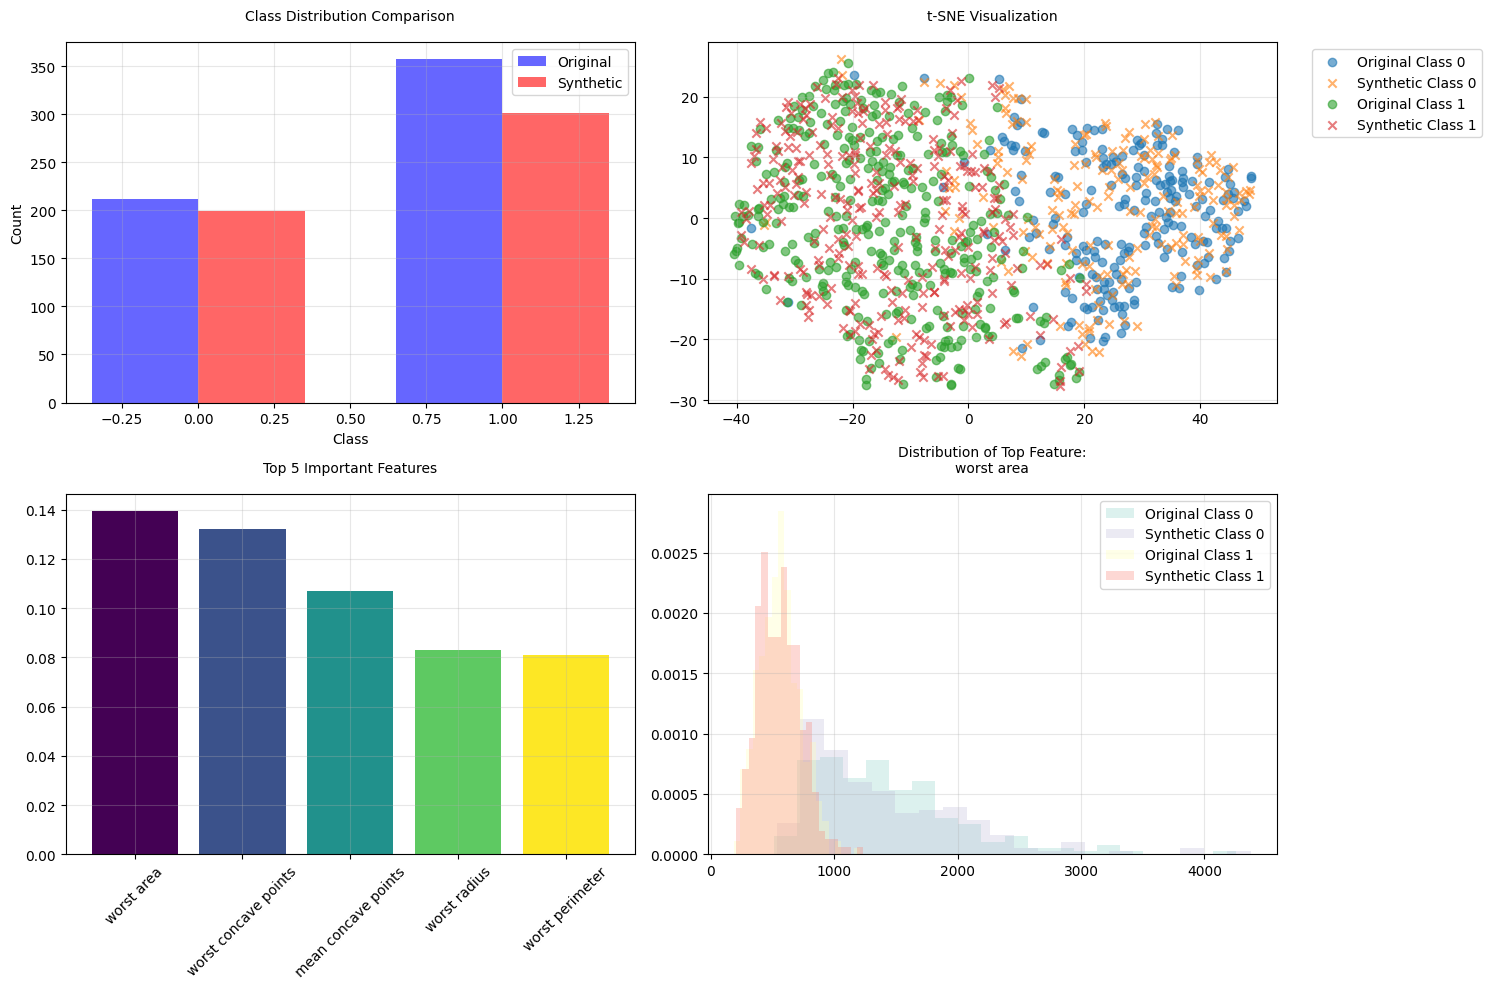

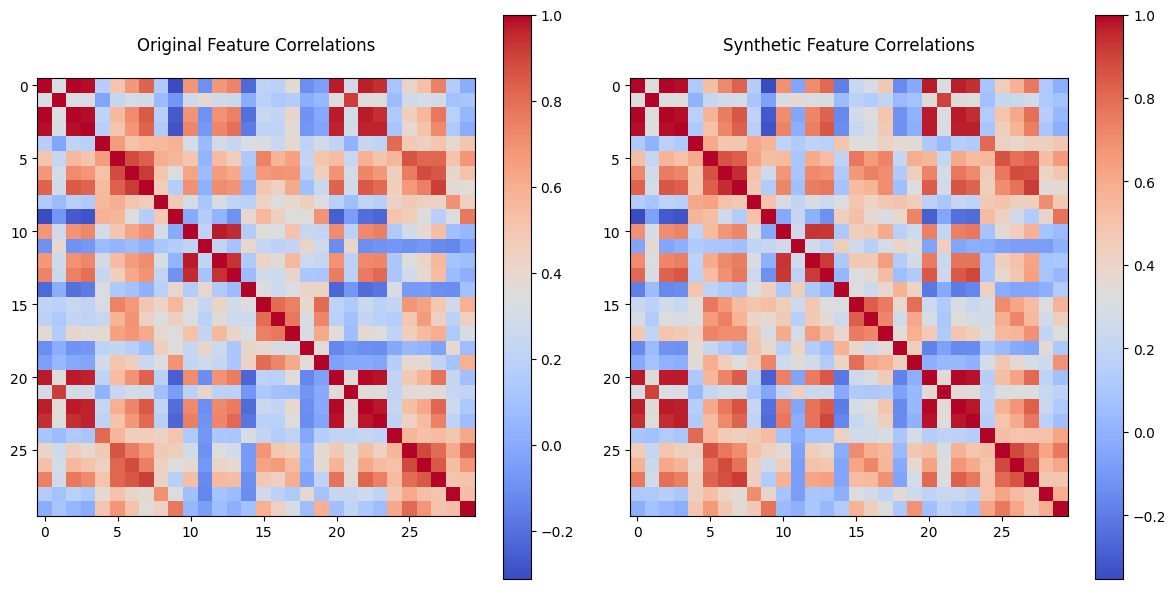

In [9]:
visualize_classification_results(
    X, y, synthetic_df.drop(columns=["target"]).values, synthetic_df["target"].values,
    feature_names=load_breast_cancer().feature_names
)

Step 0/1000
Step 100/1000
Step 200/1000
Step 300/1000
Step 400/1000
Step 500/1000
Step 600/1000
Step 700/1000
Step 800/1000
Step 900/1000


/Users/alp.erkent/Projects/synthdata/.venv/lib/python3.11/site-packages/tabpfn/validation.py:142: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


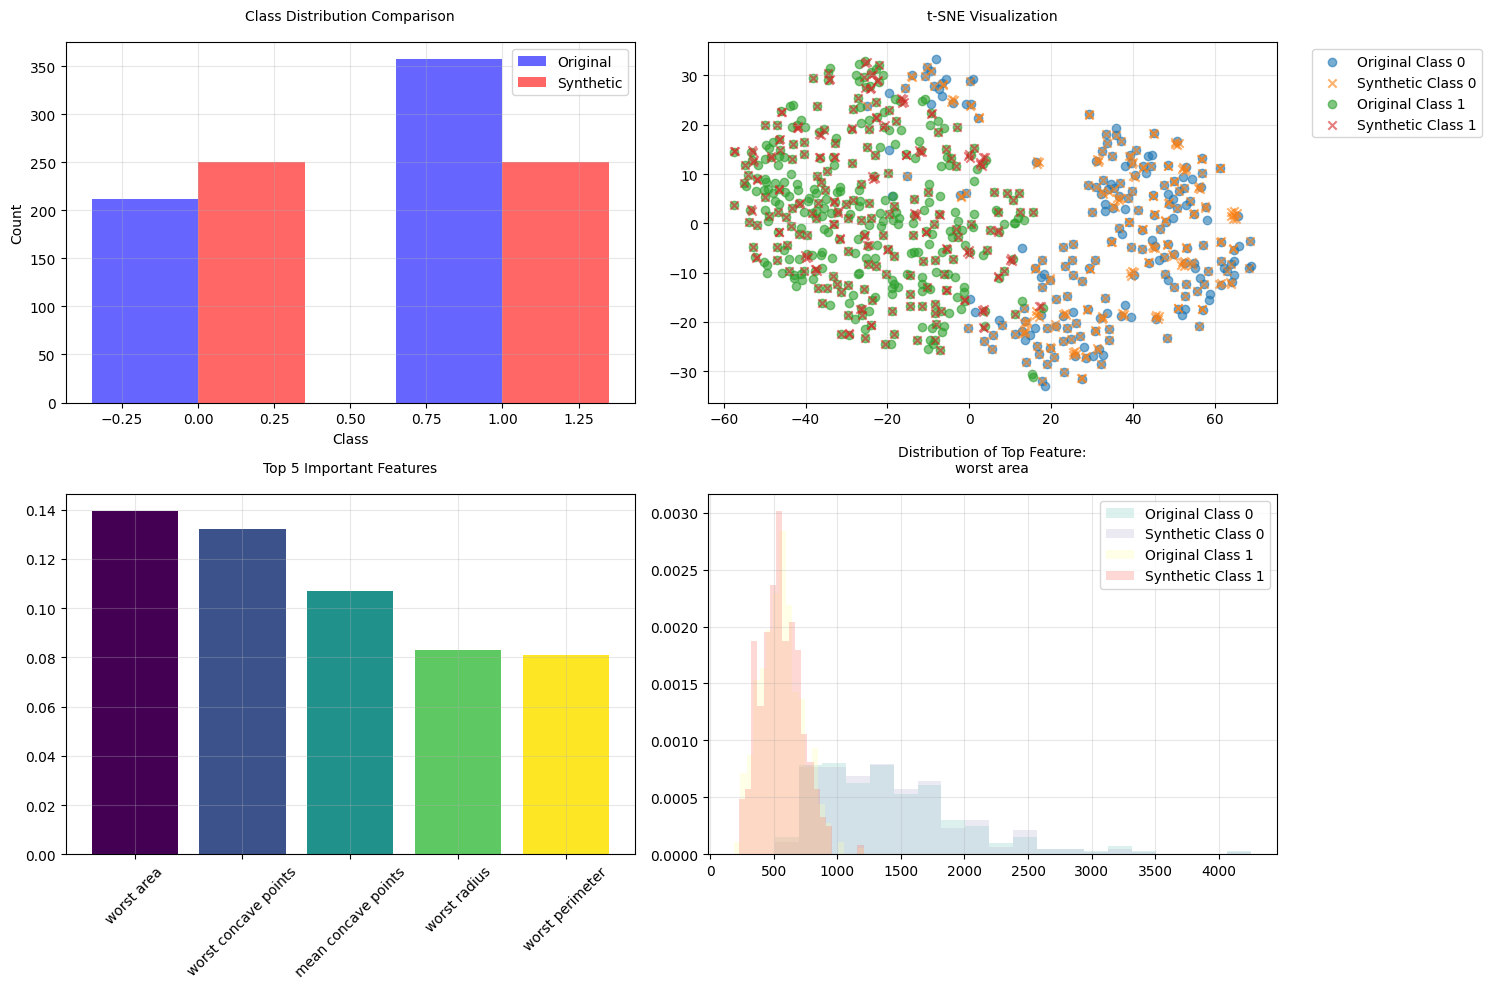

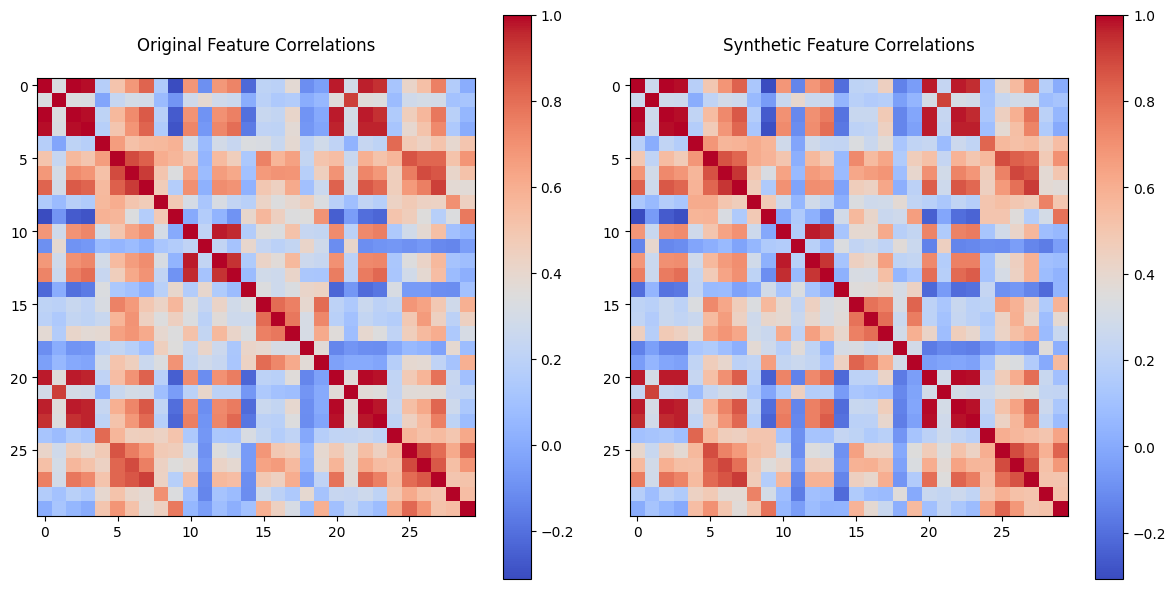

In [10]:
X, y = load_breast_cancer(return_X_y=True)

generator = TabPFGen(n_sgld_steps=1000)

X_synth, y_synth = generator.generate_classification(
    X, y,
    n_samples=500,
    balance_classes=True
)

visualize_classification_results(
    X, y, X_synth, y_synth,
    feature_names=load_breast_cancer().feature_names
)